# Gaussian process regression as a continuous-discrete state-space model

## Introduction

Gaussian process (GP) regression is a common Bayesian regression technique, which arises from placing a prior on functions $f \colon \mathbb{R}^{d_x} \to \mathbb{R}^{d_y}$. This prior is typically explained through a kernel approach in Bayesian machine learning (cf. [1]), but for certain kernels and $d_x = 1$, the functional can also be expressed as a linear time-invariant (LTI) SDE, and the corresponding regression problem becomes a CD-SSM smoothing problem. 

In this notebook, we illustrate how GP regression with the Matérn-3/2 kernel can be written in `cd-dynamax`, matching the kernel-based solution in [`tinygp`](https://tinygp.readthedocs.io/en/stable/) near-exactly. We also compare a `cd-dynamax`-based implementation to the recent addition of CD-SSM-based GPs in `tinygp`.

For more information on the SSM view of scalar GPs, the reader is encouraged to read the classical tutorial article [2], the more recent tutorial article [3], or Chapters 11 and 12 of the textbook [4].

You will need `tinygp` in order to run this notebook (`pip install "tinygp>=0.3.0"`).

## Mathematical Description

GP regression is typically introduced from a kernel view. In particular, consider a positive semidefinite function $\kappa \colon \mathbb{R} \times \mathbb{R} \to \mathbb{R}$. A GP (with prior mean zero) encodes the prior that the values of the function $f(t)$ at any finite set of times $t_1, \dots, t_N$ is jointly Gaussian with mean $0$ and covariance matrix $K$ whose entries are $K_{ij} = \kappa(t_i, t_j)$.

Assuming i.i.d. for the observations $y_1, \dots, y_K$, we may write the corresponding model as

$$
f \sim \mathcal{GP}(0, \kappa), \qquad
y_n = f(t_n) + \epsilon_i, \qquad
\epsilon_k \sim \mathcal{N}(0, \sigma_y^2).
$$

A common kernel is given by the Matérn-3/2 kernel:

$$
\kappa(\tau)
= \sigma_f^2 (1 + \lambda \tau)\exp(-\lambda \tau),
\qquad
\lambda = \frac{\sqrt{3}}{\ell},
\qquad
\tau = |t-t'|,
$$

where $\sigma_f$ is the marginal standard deviation and $\ell$ is the
length scale.

Typically, the GP solution based on kernels requires the inversion of $K$, which becomes expensive quickly as the number of data points $N$ increases. It turns out that for the Matérn-3/2 kernel, we can derive an SDE with the exact same prior covariance as the kernel-based GP $f$, and thus, we can compute solutions in linear time in $N$, rather than the cubic time required to compute $K^{-1}$. While we specialize to the Matérn-3/2 kernel in this example, similar results are available for a wide variety of kernels; in fact, any GP with a stationary kernel can be approximated arbitrarily well this way.

To write this in a corresponding state-space model, we define an SDE over $f$ and $\dot f = \partial f / \partial t$, i.e., $\mathbf{z}(t) = [f(t),\, \dot f(t)]^\mathsf{T}$. Then we obtain an SDE whose stationary covariance is exactly that of $f$ as follows:

$$
\mathrm{d}\mathbf{z}
=
\underbrace{\begin{bmatrix}
0 & 1 \\
-\lambda^2 & -2\lambda
\end{bmatrix}}_{\mathbf{F}}
\mathbf{z}\,\mathrm{d}t
+
\underbrace{\begin{bmatrix}0\\1\end{bmatrix}}_{\mathbf{L}}
\mathrm{d}\beta(t),
\qquad
y_i =
\underbrace{\begin{bmatrix}1&0\end{bmatrix}}_{\mathbf{H}}
\mathbf{z}(t_n) + \epsilon_i,
$$

with white-noise spectral density
$q_c = 4\lambda^3\sigma_f^2$. We initialize with the stationary covariance,

$$
\mathbf{z}(t_0) \sim \mathcal{N}(\mathbf{0}, \mathbf{P}_\infty),
\qquad
\mathbf{P}_\infty =
\begin{bmatrix}
\sigma_f^2 & 0 \\
0 & \lambda^2\sigma_f^2
\end{bmatrix},
$$

which can be derived by solving the Lyapunov equation.

We then may use Kalman filtering to compute $p(\mathbf{z}(t_n)\mid y_{1:N})$,, and smoothing to compute $p(\mathbf{z}(t_n)\mid y_{1:N})$. Since each of these distributions are Gaussian, it is simple to marginalize $z$ to obtain $p(f(t_n) \mid y_{1:N})$, the standard GP posterior.

## Code Demonstration

We now demonstrate how to construct the corresponding CD-SSM in `cd-dynamax`, and compare to `tinygp`.

### Imports and Plotting Helpers

In [1]:
from time import perf_counter

import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import jax.random as jr
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from cd_dynamax import ContDiscreteLinearGaussianSSM, KFHyperParams
from cd_dynamax.dynamax.parameters import ParameterProperties
from tinygp import GaussianProcess
from tinygp.kernels import quasisep
from tinygp.solvers import DirectSolver
from tinygp.solvers.kalman import KalmanSolver

In [2]:
COLORS = {
    "cd": "#E64B35",
    "gp": "#009E73",
    "dense": "#5F5F5F",
    "truth": "#222222",
    "observations": "#6F6F6F",
}

mpl.rcParams.update(
    {
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.family": "DejaVu Sans",
        "mathtext.fontset": "dejavusans",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.9,
        "lines.linewidth": 2.0,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "legend.frameon": False,
    }
)


def despine(ax):
    """Use open axes for one-dimensional regression plots."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out")


def add_uncertainty(ax, x, mean, variance, color, label):
    """Plot a mean with nested 50% and 95% Gaussian intervals."""
    standard_deviation = np.sqrt(np.maximum(variance, 0.0))
    ax.fill_between(
        x,
        mean - 1.96 * standard_deviation,
        mean + 1.96 * standard_deviation,
        color=color,
        alpha=0.10,
        linewidth=0,
    )
    ax.fill_between(
        x,
        mean - 0.674 * standard_deviation,
        mean + 0.674 * standard_deviation,
        color=color,
        alpha=0.20,
        linewidth=0,
    )
    return ax.plot(x, mean, color=color, linewidth=2.2, label=label)[0]

### Data Generation

We test on noisy observations from a test function $f(t) = 0.65 \sin(1.25 t) + 0.3 \cos(2.4 t)$.

In [3]:
num_observations = 64
sigma_f = 1.0
length_scale = 1.2
sigma_y = 0.18

key_times, key_noise = jr.split(jr.PRNGKey(7))
t_train = jnp.sort(jr.uniform(key_times, (num_observations,), minval=0.0, maxval=10.0))


def true_function(t):
    return 0.65 * jnp.sin(1.25 * t) + 0.30 * jnp.cos(2.4 * t)


f_train = true_function(t_train)
y_train = f_train + sigma_y * jr.normal(key_noise, t_train.shape)

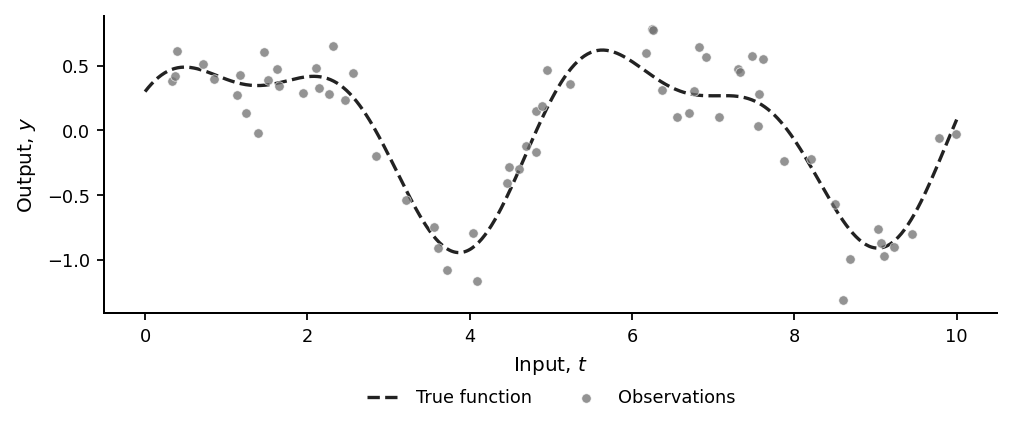

In [4]:
t_plot = jnp.linspace(0.0, 10.0, 500)

fig, ax = plt.subplots(figsize=(7.2, 3.0))
ax.plot(
    t_plot,
    true_function(t_plot),
    color=COLORS["truth"],
    linestyle="--",
    linewidth=1.5,
    label="True function",
)
ax.scatter(
    t_train,
    y_train,
    s=18,
    color=COLORS["observations"],
    alpha=0.75,
    edgecolor="white",
    linewidth=0.35,
    label="Observations",
    zorder=3,
)
ax.set(xlabel="Input, $t$", ylabel="Output, $y$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=2)
despine(ax)
fig.subplots_adjust(bottom=0.26)
plt.show()

### Making the Matérn-$3/2$ Model in `cd_dynamax`

We next construct the correspodning LTI CD-SSM. `cd_dynamax` represents process noise as $\mathbf{L}\mathbf{Q}_c\mathbf{L}^\mathsf{T}$; we therefore use $\mathbf{L}=\mathbf{I}_2$ and place $q_c$ in the lower-right entry of $\mathbf{Q}_c$; this is algebraically identical to the vector form above.

In [5]:
lam = jnp.sqrt(3.0) / length_scale

F = jnp.array(
    [
        [0.0, 1.0],
        [-(lam**2), -2.0 * lam],
    ]
)
P_infinity = jnp.diag(jnp.array([sigma_f**2, (lam * sigma_f) ** 2]))
Q_c = jnp.diag(jnp.array([0.0, 4.0 * lam**3 * sigma_f**2]))
H = jnp.array([[1.0, 0.0]])
R = jnp.array([[sigma_y**2]])


def fixed(value):
    """Package a fixed cd_dynamax parameter."""
    return {
        "params": value,
        "props": ParameterProperties(trainable=False),
    }


model = ContDiscreteLinearGaussianSSM(
    state_dim=2,
    emission_dim=1,
    has_dynamics_bias=False,
    has_emissions_bias=False,
)

params, _ = model.initialize(
    initial_mean=fixed(jnp.zeros(2)),
    initial_cov=fixed(P_infinity),
    dynamics_weights=fixed(F),
    dynamics_diffusion_coefficient=fixed(jnp.eye(2)),
    dynamics_diffusion_cov=fixed(Q_c),
    emission_weights=fixed(H),
    emission_cov=fixed(R),
)

# A small fixed step makes numerical push-forwards agree closely with the
# analytic Matérn transition used by tinygp.
kf_hyperparams = KFHyperParams(diffeqsolve_settings={"dt0": 0.01})

### Solving for the Filtering and Smoothing Distributions

We evaluate filtering at the observation times; for smoothing, for visualization purposes, we solve for results on a dense grid, by inserting "missing observations."

In [6]:
t_emissions = t_train[:, None]
emissions = y_train[:, None]

filtered = model.filter(
    params=params,
    emissions=emissions,
    t_emissions=t_emissions,
    filter_hyperparams=kf_hyperparams,
    warn=False,
)

# Combine a dense prediction grid with the exact observation times.
t_smooth = jnp.unique(jnp.concatenate((t_plot, t_train)))
observation_indices = jnp.searchsorted(t_smooth, t_train)

smoothing_emissions = jnp.full((len(t_smooth), 1), jnp.nan)
smoothing_emissions = smoothing_emissions.at[observation_indices, 0].set(y_train)
smoothing_mask = jnp.zeros(len(t_smooth), dtype=bool)
smoothing_mask = smoothing_mask.at[observation_indices].set(True)

smoothed = model.smoother(
    params=params,
    emissions=smoothing_emissions,
    t_emissions=t_smooth[:, None],
    filter_hyperparams=kf_hyperparams,
    emission_mask=smoothing_mask,
    warn=False,
)

cd_filter_mean = np.asarray(filtered.filtered_means[:, 0])
cd_filter_variance = np.asarray(filtered.filtered_covariances[:, 0, 0])
cd_smooth_mean = np.asarray(smoothed.smoothed_means[:, 0])
cd_smooth_variance = np.asarray(smoothed.smoothed_covariances[:, 0, 0])

Running KF smoother type = cd_smoother_1
Running KF smoother type 1


### Comparison with the Kernel-Based Solution

To validate the results of the above model, we compare it to the typical kernel-based formulation provided by the Jax package `tinygp`. For smoothing, we can do direct computation of the typical GP posterior; for filtering, we solve $p(f(t_n) | y_{1:n})$ for all $n = 1, \dots, N$. This reflects that online learning with typical GPs is rather difficult, an additional benefit of the SSM-based approach.

First, we solve for the smoothing solution, which is a bit more direct:

In [7]:
kernel = quasisep.Matern32(scale=length_scale, sigma=sigma_f)

dense_gp = GaussianProcess(
    kernel,
    t_train,
    diag=sigma_y**2,
    solver=DirectSolver,
)
dense_posterior = dense_gp.condition(
    y_train,
    X_test=t_smooth,
    diag=0.0,
).gp

gp_smooth_mean = np.asarray(dense_posterior.mean)
gp_smooth_variance = np.asarray(dense_posterior.variance)

Next, for the more exhaustive filtering solution (which actually requires $\mathcal{O}(N^4)$ computations in this naïve implementation):

In [8]:
def tinygp_prefix_marginals(kernel, x, y, noise_variance):
    """Compute p(f_i | y_1:i) using dense GP conditioning on each prefix."""
    prior_covariance = np.asarray(kernel(x, x))
    observations = np.asarray(y)
    means = np.empty(len(x))
    variances = np.empty(len(x))

    for i in range(len(x)):
        covariance_i = prior_covariance[: i + 1, : i + 1]
        covariance_i = covariance_i + noise_variance * np.eye(i + 1)
        cross_covariance = prior_covariance[i, : i + 1]

        chol = np.linalg.cholesky(covariance_i)
        alpha = np.linalg.solve(chol.T, np.linalg.solve(chol, observations[: i + 1]))
        projected = np.linalg.solve(chol, cross_covariance)

        means[i] = cross_covariance @ alpha
        variances[i] = prior_covariance[i, i] - projected @ projected

    return means, variances


gp_filter_mean, gp_filter_variance = tinygp_prefix_marginals(
    kernel,
    t_train,
    y_train,
    sigma_y**2,
)


The `cd-dynamax` and `tinygp` results consequently agree to small error (on account of the numerical integration of the CD-SSM):

In [9]:
agreement = pd.DataFrame(
    {
        "mean error": [
            np.max(np.abs(cd_filter_mean - gp_filter_mean)),
            np.max(np.abs(cd_smooth_mean - gp_smooth_mean)),
        ],
        "variance error": [
            np.max(np.abs(cd_filter_variance - gp_filter_variance)),
            np.max(np.abs(cd_smooth_variance - gp_smooth_variance)),
        ],
    },
    index=["Filtering", "Smoothing"],
)
display(agreement.style.format("{:.2e}"))

assert agreement.to_numpy().max() < 1e-6

,mean error,variance error
Filtering,1.97e-09,1.88e-09
Smoothing,5.09e-08,3.61e-08


We can also visualize this:

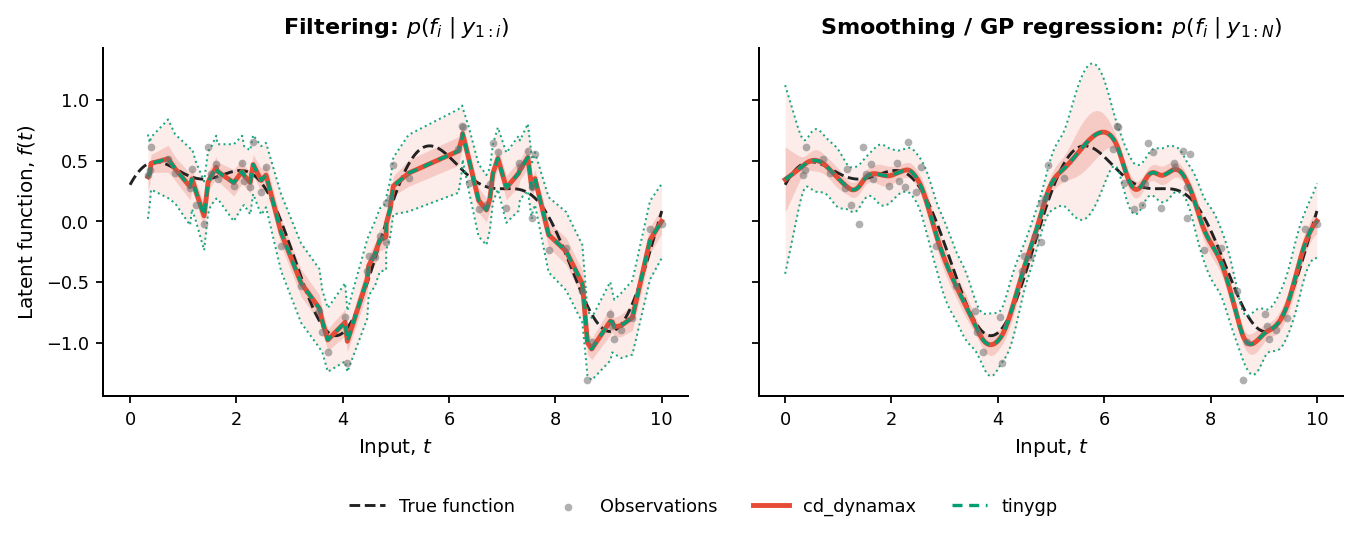

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4), sharex=True, sharey=True)

solutions = [
    (
        "Filtering: $p(f_i\\mid y_{1:i})$",
        t_train,
        cd_filter_mean,
        cd_filter_variance,
        gp_filter_mean,
        gp_filter_variance,
    ),
    (
        "Smoothing / GP regression: $p(f_i\\mid y_{1:N})$",
        t_smooth,
        cd_smooth_mean,
        cd_smooth_variance,
        gp_smooth_mean,
        gp_smooth_variance,
    ),
]

for ax, (title, x, cd_mean, cd_variance, gp_mean, gp_variance) in zip(
    axes, solutions
):
    ax.plot(
        t_plot,
        true_function(t_plot),
        color=COLORS["truth"],
        linestyle="--",
        linewidth=1.3,
        label="True function",
    )
    ax.scatter(
        t_train,
        y_train,
        s=12,
        color=COLORS["observations"],
        alpha=0.55,
        linewidth=0,
        label="Observations",
        zorder=3,
    )
    add_uncertainty(
        ax,
        x,
        cd_mean,
        cd_variance,
        COLORS["cd"],
        "cd_dynamax",
    )

    gp_standard_deviation = np.sqrt(np.maximum(gp_variance, 0.0))
    ax.plot(
        x,
        gp_mean,
        color=COLORS["gp"],
        linestyle=(0, (3, 2)),
        linewidth=1.5,
        label="tinygp",
    )
    ax.plot(
        x,
        gp_mean - 1.96 * gp_standard_deviation,
        color=COLORS["gp"],
        linestyle=":",
        linewidth=0.9,
        alpha=0.9,
    )
    ax.plot(
        x,
        gp_mean + 1.96 * gp_standard_deviation,
        color=COLORS["gp"],
        linestyle=":",
        linewidth=0.9,
        alpha=0.9,
    )
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Input, $t$")
    despine(ax)

axes[0].set_ylabel("Latent function, $f(t)$")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.01),
    ncol=4,
)
fig.subplots_adjust(bottom=0.24, wspace=0.12)
plt.show()

## Scaling Experiment

A primary motivation for using the CD-SSM formulation of the GP is its reduction in computational complexity: the kernel-based GP regression algorithm must invert an $N \times N$ covariance matrix, requiring $\mathcal{O}(N^3)$ time and $\mathcal{O}(N^2)$ memory, whilst filtering requires $\mathcal{O}(Nd_z^3)$ time (where, in the case of the Matérn-3/2 kernel, $d_z = 2$).

We compare marginal log-likelihood evaluation with:

1. the `cd_dynamax` continuous-discrete Kalman filter;
2. `tinygp` with its dense `DirectSolver`; and
3. `tinygp` with its state-space `KalmanSolver`.

The last of these is `tinygp`'s implementation of our exact CD-SSM setup. Since their method is tuned exactly to the GP use case, it is expected to be somewhat faster; nevertheless, our results should scale similarly with $N$, and have similar numerical outputs.

### Benchmark Setup

We derive a benchmark such that all functions are "warmed up," JAX-compiled, and then ran five times. We report the wall-clock time of the median of these five runs.

In [11]:
@jax.jit
def cddynamax_log_probability(t, y):
    posterior = model.filter(
        params=params,
        emissions=y[:, None],
        t_emissions=t[:, None],
        filter_hyperparams=kf_hyperparams,
        output_fields=["marginal_loglik"],
        warn=False,
    )
    return posterior.marginal_loglik


@jax.jit
def tinygp_dense_log_probability(t, y):
    gp = GaussianProcess(
        kernel,
        t,
        diag=sigma_y**2,
        solver=DirectSolver,
    )
    return gp.log_probability(y)


@jax.jit
def tinygp_ssm_log_probability(t, y):
    gp = GaussianProcess(
        kernel,
        t,
        diag=sigma_y**2,
        solver=KalmanSolver,
    )
    return gp.log_probability(y)


def synchronize(value):
    return float(jax.block_until_ready(value))


def median_runtime(function, t, y, repeats=5):
    synchronize(function(t, y))  # Compile and warm up.
    runtimes = []
    for _ in range(repeats):
        start = perf_counter()
        synchronize(function(t, y))
        runtimes.append(perf_counter() - start)
    return np.median(runtimes)

In [12]:
sizes = np.array([64, 128, 256, 512, 1024, 2048, 4096])
benchmark_rows = []

methods = {
    "cd_dynamax": cddynamax_log_probability,
    "tinygp dense": tinygp_dense_log_probability,
    "tinygp SSM": tinygp_ssm_log_probability,
}

for size in sizes:
    t_benchmark = jnp.linspace(0.0, 12.0, size)
    y_benchmark = true_function(t_benchmark)

    log_probabilities = {
        name: synchronize(function(t_benchmark, y_benchmark))
        for name, function in methods.items()
    }

    for name, function in methods.items():
        benchmark_rows.append(
            {
                "N": size,
                "Method": name,
                "Median time [s]": median_runtime(
                    function,
                    t_benchmark,
                    y_benchmark,
                ),
                "Log probability": log_probabilities[name],
            }
        )

benchmark_results = pd.DataFrame(benchmark_rows)
display(
    benchmark_results.pivot(
        index="N",
        columns="Method",
        values="Median time [s]",
    ).style.format("{:.3e}")
)

Method,cd_dynamax,tinygp SSM,tinygp dense
N,,,
64,1.814e-03,2.508e-05,6.342e-05
128,2.679e-03,3.004e-05,1.408e-04
256,3.145e-03,3.496e-05,3.020e-04
512,3.536e-03,4.654e-05,8.651e-04
1024,5.586e-03,6.988e-05,4.790e-03
2048,7.350e-03,1.132e-04,3.748e-02
4096,1.497e-02,2.120e-04,1.932e-01


All three likelihoods describe the same GP. We check this explicitly before
plotting the timings.

In [13]:
log_probability_table = benchmark_results.pivot(
    index="N",
    columns="Method",
    values="Log probability",
)
maximum_log_probability_difference = (
    log_probability_table.max(axis=1) - log_probability_table.min(axis=1)
).max()

print(
    "Maximum absolute log-probability difference: "
    f"{maximum_log_probability_difference:.2e}"
)
assert maximum_log_probability_difference < 1e-4

Maximum absolute log-probability difference: 6.14e-06


### Results

We now plot the results on log-log scale to examine the scaling of each solution; on log-log scale, we'd expect a linear relationship in wall-clock time, with the kernel-based method having a slope of $3$ and the state-space methods having a slope of $1$.

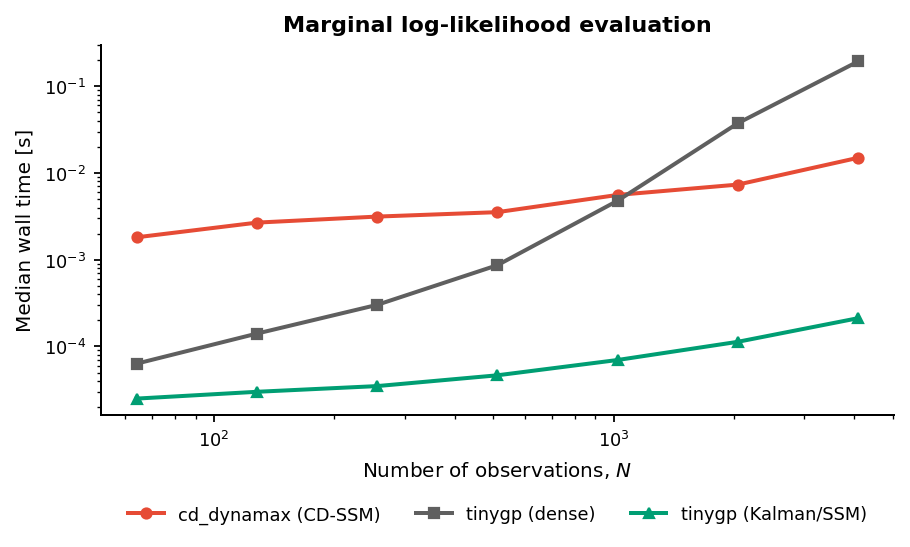

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))

plot_styles = {
    "cd_dynamax": {
        "color": COLORS["cd"],
        "marker": "o",
        "label": "cd_dynamax (CD-SSM)",
    },
    "tinygp dense": {
        "color": COLORS["dense"],
        "marker": "s",
        "label": "tinygp (dense)",
    },
    "tinygp SSM": {
        "color": COLORS["gp"],
        "marker": "^",
        "label": "tinygp (Kalman/SSM)",
    },
}

for name, style in plot_styles.items():
    subset = benchmark_results[benchmark_results["Method"] == name]
    ax.plot(
        subset["N"],
        subset["Median time [s]"],
        color=style["color"],
        marker=style["marker"],
        markersize=4.5,
        linewidth=1.8,
        label=style["label"],
    )

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Number of observations, $N$",
    ylabel="Median wall time [s]",
)
ax.set_title("Marginal log-likelihood evaluation", fontweight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.20), ncol=3)
despine(ax)
fig.subplots_adjust(bottom=0.27)
plt.show()

Indeed, we see that `cd-dynamax` is slower than `tinygp`, but scales similarly and approximately linearly in `N`, whilst the kernel-based GP scales approximately cubically. This means that already for $N \approx 10^3$, exact solutions are significantly faster to compute with `cd-dynamax` than with `tinygp` for dense matrices, and even for $N = 64$, `tinygp`'s SSM formulation is preferrable.

## References

1. C. E. Rasmussen and C. K. I. Williams, *Gaussian Processes for Machine
   Learning*. MIT Press, 2006.
   [Online edition](https://gaussianprocess.org/gpml/).
2. S. Särkkä, A. Solin, and J. Hartikainen, “Spatiotemporal Learning via
   Infinite-Dimensional Bayesian Filtering and Smoothing: A Look at Gaussian
   Process Regression Through Kalman Filtering,” *IEEE Signal Processing
   Magazine*, vol. 30, no. 4, pp. 51–61, July 2013.
   [doi:10.1109/MSP.2013.2246292](https://doi.org/10.1109/MSP.2013.2246292).
3. D. Waxman, F. Llorente, and P. M. Djurić, “Sequential Inference for
   Gaussian Processes: A Signal Processing Perspective,” to appear in 
   *IEEE Signal Processing Magazine*, 2026.
   [arXiv:2604.28163](https://arxiv.org/abs/2604.28163).
4. S. Särkkä and A. Solin, *Applied Stochastic Differential Equations*,
   Institute of Mathematical Statistics Textbooks, vol. 10.
   Cambridge University Press, 2019.
   [doi:10.1017/9781108186735](https://doi.org/10.1017/9781108186735).